# Construction et analyse d’une surface de volatilité implicite 

## 1. Introduction 

Dans le modèle de Black-Scholes, la volatilité du sous-jacent est supposée constante. En pratique, les prix observés sur le marché montrent que la volatilité implicite varie selon le strike et la maturité de l’option. Elle peut donc être représentée comme une fonction : $$ \sigma_{\mathrm{imp}} = f(K,T) $$ où : 
- $K$ désigne le strike de l’option ; 
- $T$ désigne le temps restant jusqu’à l’échéance. 

Pour une maturité donnée, la représentation de la volatilité implicite selon le strike peut faire apparaître un **smile** ou un **skew de volatilité**. Lorsque plusieurs strikes et plusieurs maturités sont considérés simultanément, les volatilités obtenues forment une surface de volatilité implicite. 

### Objectifs 
Le projet s'articule autour de cinq étapes :
1. récupérer et nettoyer les données d’options disponibles sur Yahoo Finance;
2. calculer la moneyness et la maturité de chaque option ; 
3. recalculer les volatilités implicites par inversion de la formule de Black-Scholes ; 
4. comparer les résultats aux volatilités fournies par Yahoo Finance ; 
5. analyser les smiles, les skews et la surface de volatilité obtenue. 

### Cadre théorique
 Dans le modèle de Black-Scholes, le prix d’un call européen sans dividende est donné par : $$ C = S N(d_1) - K e^{-rT}N(d_2) $$ avec : $$ d_1 = \frac{\ln(S/K)+\left(r+\frac{\sigma^2}{2}\right)T} {\sigma\sqrt{T}} $$ et : $$ d_2=d_1-\sigma\sqrt{T} $$ où : 
 - $S$ est le prix du sous-jacent ; 
 - $K$ est le strike ; 
 - $T$ est la maturité ; 
 - $r$ est le taux sans risque ; 
 - $\sigma$ est la volatilité ; 
 - $N$ est la fonction de répartition de la loi normale standard. 
 
 La volatilité implicite correspond à la valeur de $\sigma$ pour laquelle le prix donné par Black-Scholes est égal au prix observé sur le marché : $$ C_{\mathrm{BS}}(S,K,T,r,\sigma_{\mathrm{imp}}) = C_{\mathrm{marché}} $$ La formule ne pouvant pas être inversée directement par rapport à $\sigma$, la volatilité implicite est obtenue à l’aide d’une méthode numérique.

## 2. Récupération et préparation des données 

Dans ce projet, nous étudions les options cotées sur l’ADR américain de TotalEnergies, identifié par le ticker `TTE`. Même si TotalEnergies est une entreprise française, les chaînes d’options disponibles sur Yahoo Finance sont plus complètes pour l’ADR coté aux États-Unis que pour l’action `TTE.PA` cotée à Paris. Le secteur énergétique est particulièrement sensible aux fluctuations des prix des matières premières ainsi qu'au contexte géopolitique. Il constitue donc un sous-jacent intéressant pour étudier la structure de la volatilité implicite.

In [59]:
import yfinance as yf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import scipy.interpolate as interpolate
from scipy.stats import norm
from scipy.optimize import brentq

In [60]:
ticker = ["TTE"]
start_date = "2025-06-01"
end_date = "2026-06-16"

In [61]:
def download_option_data(ticker, start, end):
    """
    Télécharge les données d'options nécessaires à l'analyse.
    """
    data_raw = yf.download(
        ticker,
        start=start,
        end=end,
        auto_adjust=True,  
        progress=False)
    return data_raw

In [62]:
spot_df = download_option_data(ticker, start_date, end_date)["Close"].iloc[[-1]]

obs_date = spot_df.index[0]
spots = spot_df.iloc[0]

print("Observation date:", obs_date)
print(spots)

Observation date: 2026-06-15 00:00:00
Ticker
TTE    84.07
Name: 2026-06-15 00:00:00, dtype: float64


Pour chaque échéance disponible, nous récupérons les principales informations relatives aux calls : 
- le strike ; 
- le bid et l’ask ; 
- l’open interest ; 
- la volatilité implicite fournie par Yahoo Finance ; 
- la date d’expiration. 

Le prix utilisé pour recalculer la volatilité implicite est le **mid-price** : $$ \text{Mid-price}=\frac{\text{Bid}+\text{Ask}}{2} $$ Les observations présentant un volume nul, des cotations bid-ask non exploitables ou des strikes trop éloignés du prix spot sont écartées. Ce filtrage permet de limiter l’influence des options peu liquides et des cotations potentiellement aberrantes.

In [63]:
def get_option_chain(ticker, expiration):
    """
    Récupère les chaînes d'options disponibles pour toutes les maturités.
    """
    opt = ticker.option_chain(expiration)
    calls = opt.calls
    puts = opt.puts
    return calls, puts

In [64]:
ticker_symbol = "TTE"
ticker = yf.Ticker(ticker_symbol)
expirations_ticker = ticker.options
spot_price = ticker.fast_info['lastPrice']

In [65]:
def compute_maturity(expiration, obs_date):
    """
    Calcule le temps restant jusqu'à l'échéance en années.
    """
    date = pd.to_datetime(expiration)
    T = (date - obs_date).days/365
    return T

La moneyness permet de situer le strike par rapport au prix spot du sous-jacent. Elle est définie ici par : $$ \text{Moneyness}=\frac{K}{S} $$ où $K$ est le strike et $S$ le prix spot de TotalEnergies. 

Pour un call : 
- si $K/S<1$, l’option est **in-the-money** (ITM) ; 
- si $K/S\approx1$, l’option est **at-the-money** (ATM); 
- si $K/S>1$, l’option est **out-of-the-money** (OTM). 

L’utilisation de la moneyness permet de comparer des options de strikes différents relativement au niveau actuel du sous-jacent.

In [69]:
def build_option_data(expirations, ticker, obs_date):
    """
    Construit le DataFrame contenant les caractéristiques
    des options utilisées dans l'analyse.
    """
    calls_df = pd.DataFrame()
    for exp in expirations:
        #nettoyage des données
        calls, puts = get_option_chain(ticker, exp)
        calls = calls.dropna(subset=['bid','ask','strike'])
        calls = calls[calls['bid'] > 0]
        calls = calls[calls['ask'] > calls['bid']]
        calls['mid_price'] = (calls['bid'] + calls['ask'])/2
        calls = calls[(calls['ask'] - calls['bid']) / calls['mid_price'] < 0.3]

        spot_price = ticker.fast_info['lastPrice']
        T = compute_maturity(exp, obs_date)

        calls['expiration'] = exp
        calls['maturity'] = T
        calls['spot'] = spot_price

        calls['moneyness'] = calls['strike'] / calls['spot']
        calls = calls[(calls['moneyness'] > 0) & (calls['moneyness'] < 1.3)]
        calls = calls[['strike', 'mid_price', 'expiration', 'maturity', 'spot', 'moneyness', 'impliedVolatility']]
        calls_df = pd.concat([calls_df, calls], ignore_index=True)
    return calls_df

In [67]:
print(build_option_data(expirations_ticker, ticker, obs_date).head())

   strike  mid_price  expiration  maturity       spot  moneyness  \
0    60.0      19.45  2026-07-17  0.087671  78.860001   0.760842   
1    70.0       9.40  2026-07-17  0.087671  78.860001   0.887649   
2    72.5       6.50  2026-07-17  0.087671  78.860001   0.919351   
3    75.0       4.15  2026-07-17  0.087671  78.860001   0.951052   
4    50.0      29.20  2026-08-21  0.183562  78.860001   0.634035   

   impliedVolatility  
0           2.761722  
1           1.453128  
2           0.777346  
3           0.654300  
4           0.859376  


In [68]:
tte_df = build_option_data(expirations_ticker, ticker, obs_date)
tte_df.round(4)

,strike,mid_price,expiration,maturity,spot,moneyness,impliedVolatility
0,60.0,19.450,2026-07-17,0.0877,78.86,0.7608,2.7617
1,70.0,9.400,2026-07-17,0.0877,78.86,0.8876,1.4531
2,72.5,6.500,2026-07-17,0.0877,78.86,0.9194,0.7773
3,75.0,4.150,2026-07-17,0.0877,78.86,0.9511,0.6543
4,50.0,29.200,2026-08-21,0.1836,78.86,0.6340,0.8594
...,...,...,...,...,...,...,...
129,90.0,5.450,2028-01-21,1.6027,78.86,1.1413,0.2526
130,92.5,4.750,2028-01-21,1.6027,78.86,1.1730,0.2517
131,95.0,4.200,2028-01-21,1.6027,78.86,1.2047,0.2515
132,97.5,8.000,2028-01-21,1.6027,78.86,1.2364,0.3740


## 3. Modèle de Black-Scholes

La fonction suivante calcule le prix théorique d’un call européen à l’aide de la formule de Black-Scholes. Elle sera ensuite utilisée pour retrouver la volatilité implicite correspondant au mid-price de chaque option. Le problème consiste donc à rechercher numériquement la valeur de $\sigma$ telle que : $$ C_{\mathrm{BS}}(\sigma)-C_{\mathrm{marché}}=0 $$

In [33]:
from scipy.stats import norm
from scipy.optimize import brentq
import numpy as np

def bs_call_price(S, K, T, r, sigma):
    """
    Calcule le prix d'un call européen avec le modèle de Black-Scholes.
    """
    if T <= 0:
        return max(S - K, 0)
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

## 4. Calibration de la volatilité implicite

Pour chaque option, la volatilité implicite est obtenue par inversion numérique de la formule de Black-Scholes à partir du mid-price observé. Les valeurs recalculées sont ensuite comparées aux volatilités implicites fournies par Yahoo Finance. La qualité de la calibration est évaluée à l’aide de plusieurs indicateurs : 
- l’erreur moyenne absolue, ou MAE ; 
- la racine de l’erreur quadratique moyenne, ou RMSE ; 
- l’erreur moyenne ; 
- l’erreur absolue maximale. 

Cette comparaison permet d’identifier les options pour lesquelles les deux estimations sont proches ainsi que les zones où les écarts sont plus importants.

In [34]:
def implied_vol_call(market_price, S, K, T, r):
    """
    Calcule la volatilité implicite par inversion numérique
    de la formule de Black-Scholes.
    """
    try:
        return brentq(
            lambda sigma: bs_call_price(S, K, T, r, sigma) - market_price,
            1e-6,
            5
        )
    except ValueError:
        return np.nan
    
tte_df["iv_calculated"] = tte_df.apply(
    lambda row: implied_vol_call(
        row["mid_price"], row["spot"],
        row["strike"], row["maturity"], r=0.01),
        axis=1
)

C:\Users\ynsek\AppData\Local\Temp\ipykernel_39188\4246105905.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tte_df["iv_calculated"] = tte_df.apply(


In [20]:
tte_df['error'] = tte_df['impliedVolatility'] - tte_df['iv_calculated'] 
tte_df['abs_error'] = tte_df['error'].abs()

In [21]:
mae = tte_df["abs_error"].mean()

rmse = np.sqrt((tte_df["error"]**2).mean())

mean_error = tte_df["error"].mean()

max_error = tte_df["abs_error"].max()

print(f"MAE : {mae:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"Erreur moyenne : {mean_error:.6f}")
print(f"Erreur maximale : {max_error:.6f}")

MAE : 0.083739
RMSE : 0.203117
Erreur moyenne : 0.083739
Erreur maximale : 1.831490


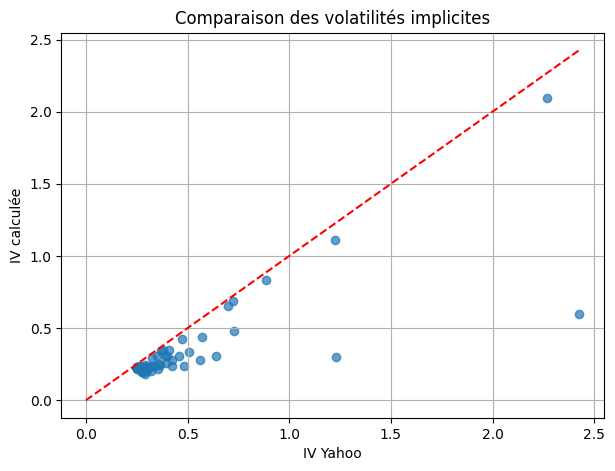

In [22]:
plt.figure(figsize=(7,5))

plt.scatter(
    tte_df["impliedVolatility"],
    tte_df["iv_calculated"],
    alpha=0.7
)

xmin = tte_df["impliedVolatility"].min()
xmax = tte_df["impliedVolatility"].max()

plt.plot([xmin,xmax],[xmin,xmax],'r--')
plt.xlabel("IV Yahoo")
plt.ylabel("IV calculée")
plt.title("Comparaison des volatilités implicites")
plt.grid(True)
plt.show()

La MAE et la RMSE indiquent que les volatilités implicites recalculées sont globalement proches de celles fournies par Yahoo Finance. Les écarts ne sont toutefois pas uniformes entre les options. Ils sont généralement plus importants lorsque le strike est éloigné du prix spot ou lorsque les contrats présentent une liquidité plus faible. Ces différences peuvent notamment provenir du prix retenu pour l’inversion, ici le mid-price, du taux sans risque utilisé, de l’absence de prise en compte des dividendes ou d’un décalage entre la mise à jour des cotations bid-ask et celle de la volatilité affichée par Yahoo Finance.

C:\Users\ynsek\AppData\Local\Temp\ipykernel_39188\808981215.py:4: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = tte_df.pivot_table(index = 'maturity_bin', columns = 'moneyness_bin',


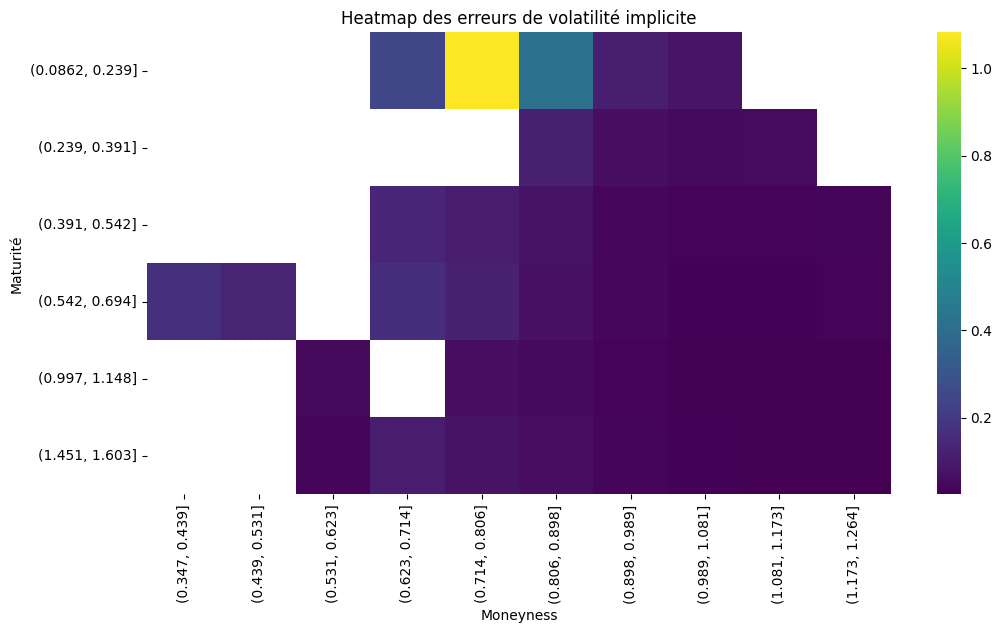

In [23]:
tte_df["moneyness_bin"] = pd.cut(tte_df["moneyness"], bins=10)
tte_df["maturity_bin"] = pd.cut(tte_df["maturity"], bins=10)

heatmap_data = tte_df.pivot_table(index = 'maturity_bin', columns = 'moneyness_bin',
                                  values = 'abs_error', aggfunc='mean')
plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, cmap="viridis")

plt.title("Heatmap des erreurs de volatilité implicite")
plt.xlabel("Moneyness")
plt.ylabel("Maturité")

plt.show()

La heatmap montre que la majorité des erreurs reste faible sur l'ensemble des couples (moneyness, maturité). Un écart plus important apparaît toutefois pour une zone correspondant à une maturité courte et à une moneyness comprise entre environ 0,7 et 0,8.

Aucune tendance marquée ne semble se dégager selon la maturité. Les écarts observés paraissent davantage liés à certaines catégories d'options qu'à une évolution systématique avec le temps restant jusqu'à l'échéance.

Il convient néanmoins de rester prudent, certaines cases de la heatmap contenant peu d'observations. Les erreurs observées peuvent alors être influencées par la faible liquidité de certains contrats ou par la présence de quelques valeurs atypiques.

## 5. Construction et analyse de la surface de volatilité implicite

Pour étudier l’évolution de la volatilité implicite selon l’échéance, plusieurs maturités réparties sur la période disponible sont sélectionnées. Pour chacune d’elles, la volatilité implicite est représentée en fonction de la moneyness. Cette représentation permet d’observer si la courbe prend la forme d’un smile symétrique ou d’un skew asymétrique, et de comparer cette structure entre les différentes maturités.

In [24]:
maturity = sorted(tte_df['maturity'].unique()) #maturités disponibles
maturities = [maturity[0], maturity[5], maturity[-1]]

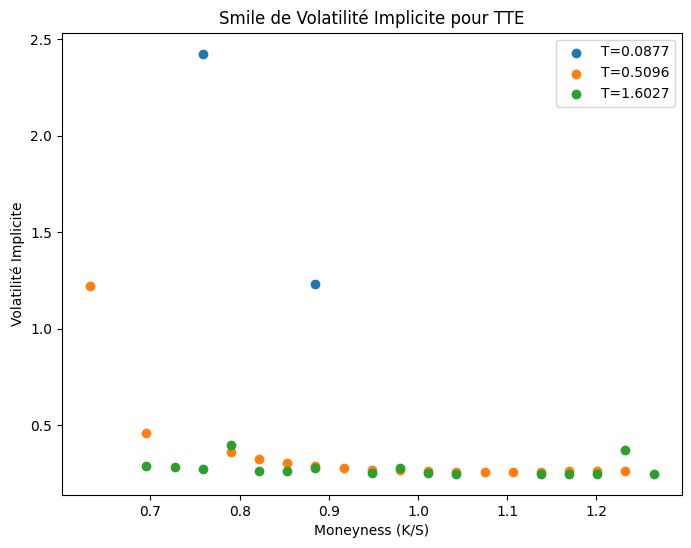

In [25]:
plt.figure(figsize=(8,6))

tte_df = tte_df[tte_df["iv_calculated"] > 0]

for i in range(3):
    df_T = tte_df[tte_df['maturity'] == maturities[i]]
    df_T = df_T.sort_values(by='moneyness')

    plt.scatter(df_T['moneyness'], df_T['impliedVolatility'], label=f'T={maturities[i]:.4f}')
plt.xlabel('Moneyness (K/S)')
plt.ylabel('Volatilité Implicite')
plt.title('Smile de Volatilité Implicite pour TTE')
plt.legend()
plt.show()

Les différentes courbes mettent en évidence que la volatilité implicite dépend de la moneyness et n'est donc pas constante.

Autour du niveau ATM, les volatilités restent relativement proches, tandis que certaines options plus éloignées présentent des niveaux plus élevés.

Selon les maturités, les courbes prennent une forme proche d'un smile ou d'un skew, traduisant une valorisation différente du risque par le marché.

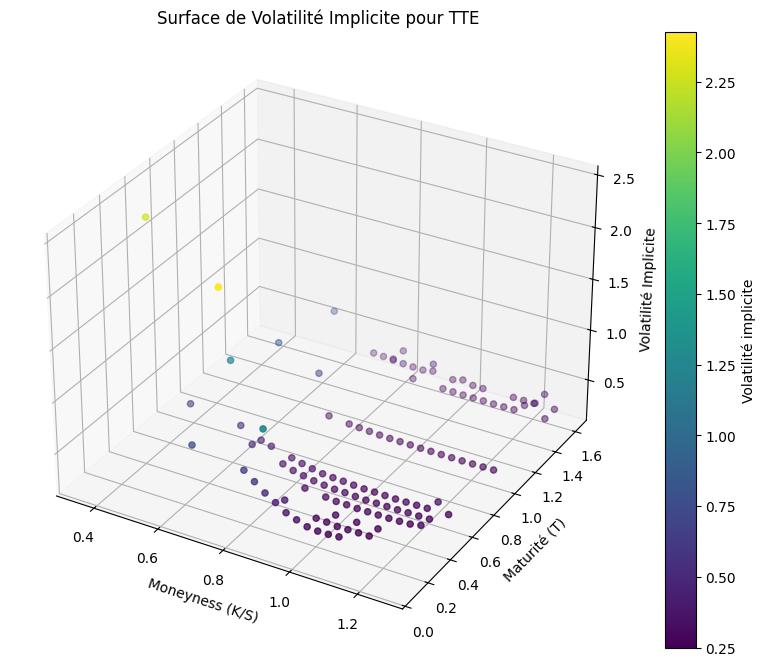

In [26]:
fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(10,8))

sc = ax.scatter(tte_df['moneyness'],
                tte_df['maturity'],
                tte_df['impliedVolatility'],
                c=tte_df['impliedVolatility'],
                cmap='viridis')

ax.set_xlabel('Moneyness (K/S)')
ax.set_ylabel('Maturité (T)')
ax.set_zlabel('Volatilité Implicite')
ax.set_title('Surface de Volatilité Implicite pour TTE')

fig.colorbar(sc, ax=ax, label='Volatilité implicite')

plt.show()

Avant l’interpolation, les observations présentant les valeurs de moneyness les plus extrêmes sont retirées afin d’éviter qu’un faible nombre de points isolés ne déforme la surface. Une grille régulière de moneyness et de maturité est ensuite construite pour interpoler les volatilités implicites observées.

In [27]:
surface_df = tte_df[['moneyness', 'maturity', 'impliedVolatility']].copy().dropna()

surface_df = surface_df[(surface_df['moneyness'] >= 0.8) &
                        (surface_df['moneyness'] <= 1.2) &
                        (surface_df['impliedVolatility'] > 0.05) &
                        (surface_df['impliedVolatility'] < 1)]

In [28]:
x = surface_df['moneyness'].values
y = surface_df['maturity'].values
z = surface_df['impliedVolatility'].values

#grille régulière sur l’axe de la moneyness
x_grid = np.linspace(x.min(), x.max(), 50)

#grille régulière sur l’axe de la maturité
y_grid = np.linspace(y.min(), y.max(), 50)

#transforme les deux vecteurs en une grille 2D
X, Y = np.meshgrid(x_grid, y_grid)

#interpolation la volatilité implicite sur la grille
Z = interpolate.griddata((x, y), z, (X, Y), method='linear')

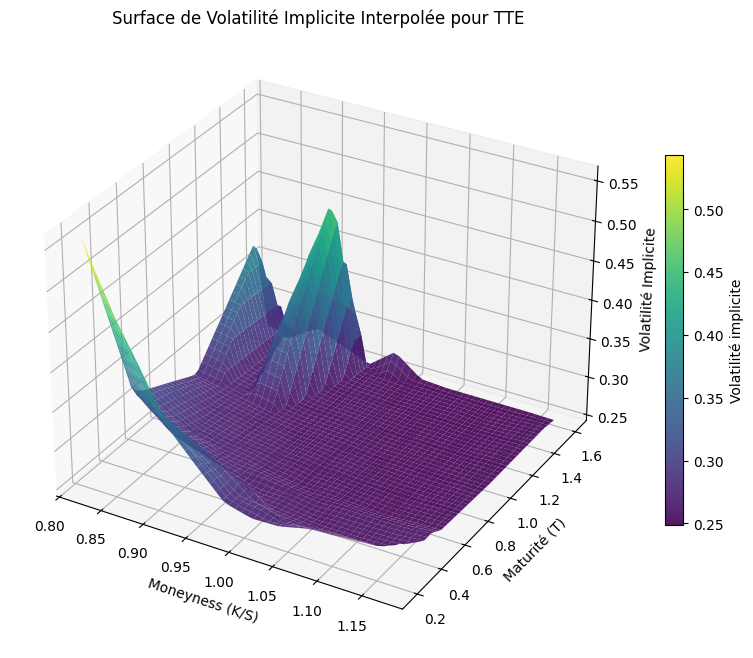

In [29]:
fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(10,8))
surf = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.9, edgecolor='none')
ax.set_xlabel('Moneyness (K/S)')
ax.set_ylabel('Maturité (T)')
ax.set_zlabel('Volatilité Implicite')
ax.set_title('Surface de Volatilité Implicite Interpolée pour TTE')
fig.colorbar(surf, ax=ax, shrink=0.6, label='Volatilité implicite')
plt.show()

La première représentation 3D correspond directement aux volatilités implicites observées. Chaque point représente une option, positionnée selon sa moneyness, sa maturité et son niveau de volatilité implicite. Autour du niveau ATM, les volatilités implicites restent relativement concentrées. Des volatilités plus élevées apparaissent dans certaines zones éloignées du niveau ATM. Le nuage de points confirme ainsi que la volatilité dépend simultanément de la moneyness et de la maturité. Les données sont ensuite interpolées sur une grille régulière afin d’obtenir une représentation continue de la surface. 

Les volatilités observées sont ensuite interpolées sur une grille régulière afin d'obtenir une représentation continue de la surface. La surface est relativement régulière dans les zones où les options sont nombreuses, notamment autour du niveau ATM. Elle devient moins stable aux extrémités, où le nombre de contrats disponibles est plus faible. Les formes observées dans ces régions doivent donc être interprétées avec davantage de prudence.

## 6. Analyse financière

### 6.1 Influence de la volatilité ($\sigma$)

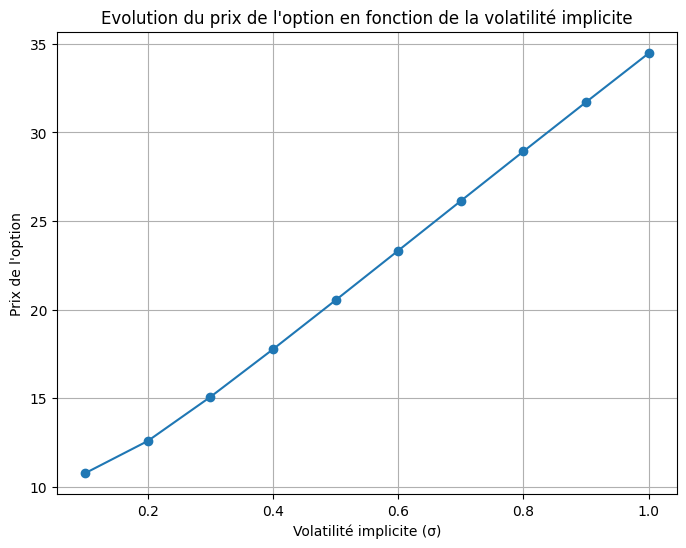

In [55]:
S = 110
K = 100
r = 0.01
T = 0.5 

sigmas = np.linspace(0.1, 1, 10)
    
x = sigmas
y = [bs_call_price(S, K, T, r, sigma) for sigma in sigmas]
plt.figure(figsize=(8,6))
plt.plot(x, y, marker='o')
plt.xlabel('Volatilité implicite (σ)')
plt.ylabel('Prix de l\'option')
plt.title('Evolution du prix de l\'option en fonction de la volatilité implicite')
plt.grid(True)
plt.show()

Le prix du call augmente avec la volatilité. Lorsque $\sigma$ est plus élevée, la distribution du prix futur du sous-jacent est plus dispersée, ce qui augmente la probabilité d’obtenir un payoff important à l’échéance. Pour l’acheteur du call, la perte reste limitée à la prime versée, tandis que le gain potentiel augmente avec le prix du sous-jacent. Cette asymétrie explique la relation positive entre la volatilité et la valeur du call.

### 6.2 Influence du prix du sous-jacent (S)

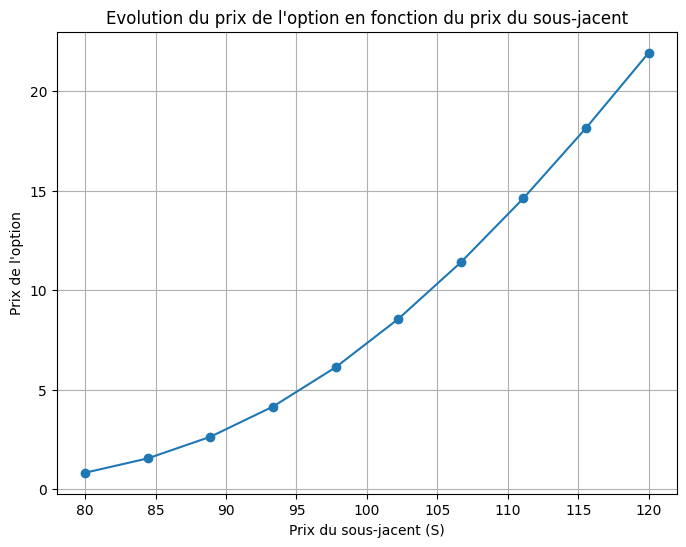

In [30]:
K = 100
r = 0.01
T = 0.5 
sigma = 0.25

S = np.linspace(80, 120, 10)
    
x = S
y = [bs_call_price(s, K, T, r, sigma) for s in S]
plt.figure(figsize=(8,6))
plt.plot(x, y, marker='o')
plt.xlabel('Prix du sous-jacent (S)')
plt.ylabel('Prix de l\'option')
plt.title('Evolution du prix de l\'option en fonction du prix du sous-jacent')
plt.grid(True)
plt.show()

Le prix du call augmente avec le prix du sous-jacent. Lorsque $S$ est très inférieur au strike, l’option est OTM et sa valeur reste faible. À mesure que $S$ se rapproche du strike, le prix du call devient plus sensible aux variations du sous-jacent. Lorsque $S$ dépasse le strike, l’option devient ITM et son prix augmente plus fortement. La relation n’est pas linéaire, car la sensibilité du call au sous-jacent, mesurée par le Delta, dépend elle-même du niveau de $S$.

### 6.3 Influence de la maturité T

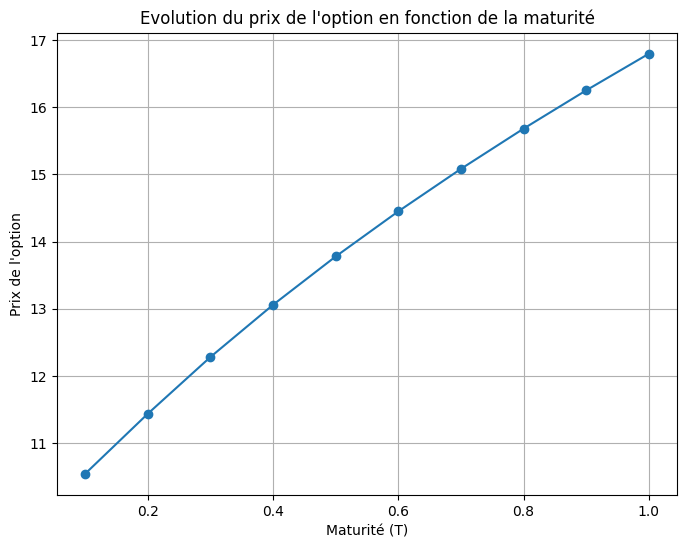

In [31]:
S = 110
K = 100
r = 0.01
sigma = 0.25

T = np.linspace(0.1, 1.0, 10)

x = T
y = [bs_call_price(S, K, t, r, sigma) for t in T]
plt.figure(figsize=(8,6))
plt.plot(x, y, marker='o')
plt.xlabel('Maturité (T)')
plt.ylabel('Prix de l\'option')
plt.title('Evolution du prix de l\'option en fonction de la maturité')
plt.grid(True)
plt.show()

Dans les paramètres retenus pour cette simulation, le prix du call augmente avec la maturité. Une échéance plus éloignée laisse davantage de temps au sous-jacent pour dépasser le strike. La valeur temps de l’option est donc plus importante. L’augmentation devient cependant moins marquée pour les maturités les plus longues, ce qui explique la forme concave de la courbe.

### 6.4 Influence du taux sans risque (r)

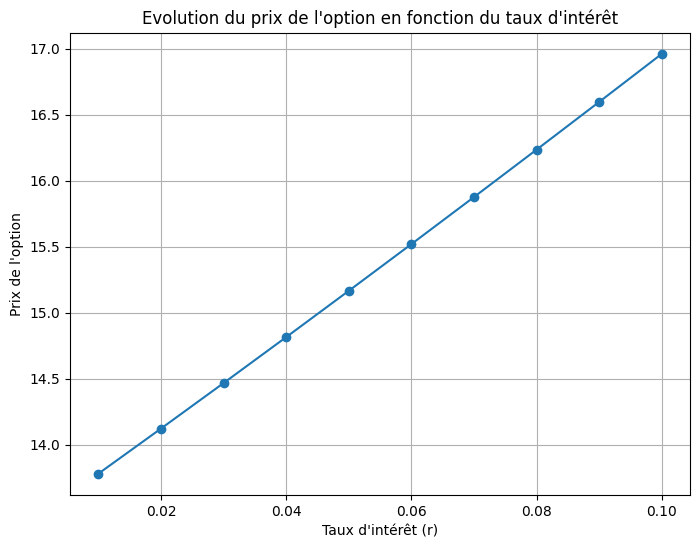

In [32]:
S = 110
K = 100
T = 0.5
sigma = 0.25

r = np.linspace(0.01, 0.1, 10)

x = r
y = [bs_call_price(S, K, T, r, sigma) for r in r]
plt.figure(figsize=(8,6))
plt.plot(x, y, marker='o')
plt.xlabel('Taux d\'intérêt (r)')
plt.ylabel('Prix de l\'option')
plt.title('Evolution du prix de l\'option en fonction du taux d\'intérêt')
plt.grid(True)
plt.show()

Le prix du call augmente légèrement avec le taux sans risque. Dans la formule de Black-Scholes, le strike actualisé est égal à $Ke^{-rT}$. Lorsque le taux $r$ augmente, la valeur actuelle du paiement du strike diminue, ce qui augmente la valeur du call. Sur l’intervalle étudié, cet effet reste toutefois plus faible que celui du prix du sous-jacent ou de la volatilité.

### 6.5 Analyse des sensibilités (Greeks)

Les Greeks permettent de mesurer la sensibilité du prix d'une option aux différents paramètres du modèle de Black-Scholes. Dans cette étude, on considère trois sensibilités principales : le Delta, le Gamma et le Vega.

Le Delta mesure la sensibilité du prix de l'option à une variation du prix du sous-jacent :

$$\Delta = \frac{\partial C}{\partial S} = N(d_1)$$

Le Gamma mesure la sensibilité du Delta à une variation du prix du sous-jacent :

$$\Gamma = \frac{\partial^2 C}{\partial S^2}
= \frac{N'(d_1)}{S\sigma\sqrt{T}}$$

Le Vega mesure la sensibilité du prix de l'option à une variation de la volatilité :

$$\text{Vega} = \frac{\partial C}{\partial \sigma}
= S\sqrt{T}N'(d_1)$$

avec :

$$d_1 =
\frac{\ln\left(\frac{S}{K}\right)+\left(r+\frac{\sigma^2}{2}\right)T}
{\sigma\sqrt{T}}$$

où $N(d_1)$ désigne la fonction de répartition de la loi normale standard et $N'(d_1)$ sa densité.

#### Delta

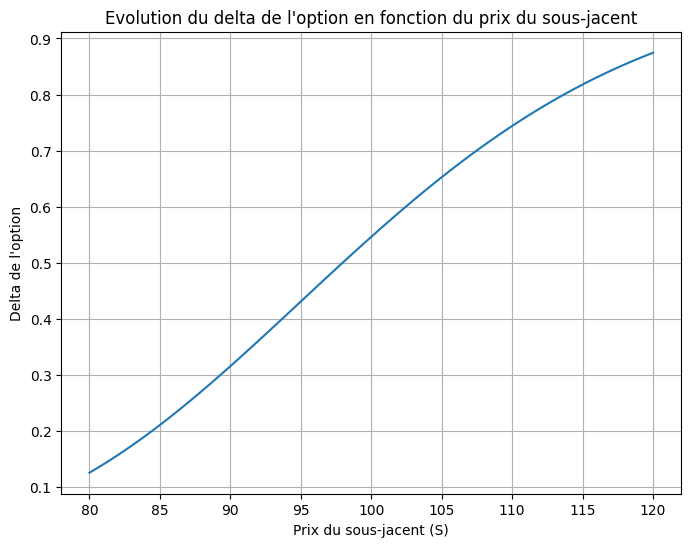

In [72]:
K = 100
r = 0.01
sigma = 0.25
T = 0.5

S = np.linspace(80, 120, 100)

d1 = [(np.log(s/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T)) for s in S]

delta = [float(norm.cdf(d)) for d in d1]

x = S
y = delta
plt.figure(figsize=(8,6))
plt.plot(x, y)
plt.xlabel('Prix du sous-jacent (S)')
plt.ylabel('Delta de l\'option')
plt.title('Evolution du delta de l\'option en fonction du prix du sous-jacent')
plt.grid(True)
plt.show()

Le Delta augmente avec le prix du sous-jacent. Une option profondément OTM présente un Delta faible, car une variation du prix du sous-jacent a peu d'effet sur la valeur de l'option. À l'inverse, une option ITM possède un Delta proche de 1, ce qui signifie que son prix évolue presque comme celui du sous-jacent. Entre ces deux situations, lorsque l'option est ATM, le Delta augmente rapidement, traduisant une forte sensibilité du prix de l'option aux variations du sous-jacent.

#### Gamma

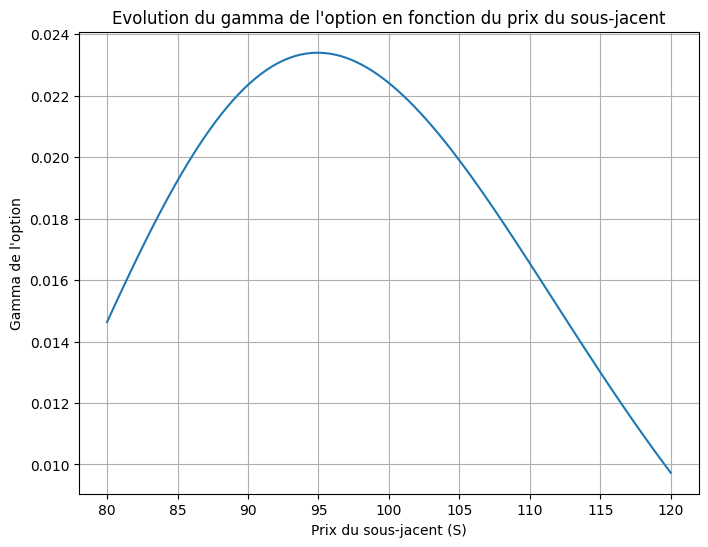

In [73]:
K = 100
r = 0.01
sigma = 0.25
T = 0.5

S = np.linspace(80, 120, 100)

d1 = [(np.log(s/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T)) for s in S]

gamma = [float(norm.pdf(d))/(s*sigma*np.sqrt(T)) for d , s in zip(d1, S)]

x = S
y = gamma
plt.figure(figsize=(8,6))
plt.plot(x, y)
plt.xlabel('Prix du sous-jacent (S)')
plt.ylabel('Gamma de l\'option')
plt.title('Evolution du gamma de l\'option en fonction du prix du sous-jacent')
plt.grid(True)
plt.show()

Le Gamma atteint son maximum lorsque l'option est proche du niveau ATM. Dans cette région, une faible variation du sous-jacent entraîne une modification importante du Delta. À l'inverse, pour les options très ITM ou très OTM, le Delta varie peu et le Gamma devient faible.

#### Vega

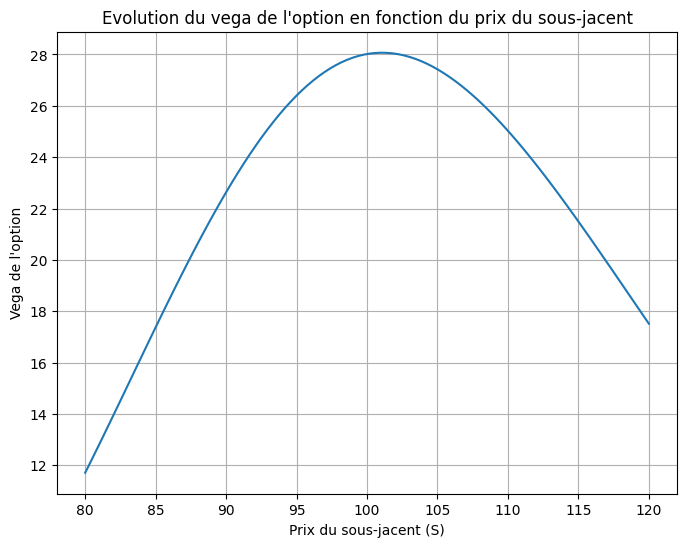

In [74]:
K = 100
r = 0.01
sigma = 0.25
T = 0.5

S = np.linspace(80, 120, 100)

d1 = [(np.log(s/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T)) for s in S]

vega = [float(norm.pdf(d))*s*np.sqrt(T) for d, s in zip(d1, S)]

x = S
y = vega
plt.figure(figsize=(8,6))
plt.plot(x, y)
plt.xlabel('Prix du sous-jacent (S)')
plt.ylabel('Vega de l\'option')
plt.title('Evolution du vega de l\'option en fonction du prix du sous-jacent')
plt.grid(True)
plt.show()

Le Vega est maximal lorsque l’option est proche du niveau ATM. Dans cette zone, une variation de la volatilité a un effet particulièrement important sur le prix de l’option. Le Vega diminue lorsque l’option devient fortement ITM ou OTM. Les options proches du niveau ATM sont donc généralement les plus informatives pour étudier et calibrer la volatilité implicite.


#### 6.6 Synthèse de l’analyse financière

Les simulations montrent que le prix du call est particulièrement sensible au prix du sous-jacent et à la volatilité. La maturité et le taux sans risque ont également un effet positif dans les paramètres retenus, mais leur influence est plus progressive.

L’analyse des Greeks complète ces observations. Le Delta augmente lorsque l’option passe d’une situation OTM à ITM, tandis que le Gamma et le Vega atteignent leurs niveaux les plus élevés autour de l’ATM.

Ces résultats expliquent pourquoi les options proches du niveau ATM occupent une place importante dans la couverture des portefeuilles et dans la calibration de la volatilité implicite.

## 7. Conclusion, limites et perspectives 

Ce notebook présente la construction d'une surface de volatilité implicite à partir des options cotées sur l’ADR américain de TotalEnergies.

Les volatilités implicites ont été recalculées par inversion numérique de la formule de Black-Scholes puis comparées aux valeurs fournies par Yahoo Finance. Les résultats obtenus montrent une bonne cohérence globale entre les deux estimations, avec des écarts plus marqués pour certaines options peu liquides ou éloignées du niveau ATM. 

L’analyse des courbes par maturité montre que la volatilité implicite varie selon la moneyness. Les formes observées ne sont pas parfaitement symétriques et font apparaître des smiles ou des skews différents selon l’échéance. La représentation en trois dimensions permet ensuite de visualiser conjointement l’effet de la moneyness et de la maturité. Les différentes visualisations mettent en évidence la dépendance de la volatilité implicite à la fois à la moneyness et à la maturité, ce qui confirme les limites de l'hypothèse de volatilité constante du modèle de Black-Scholes.

Plusieurs limites doivent néanmoins être prises en compte : 
- les calculs reposent sur le mid-price, qui ne correspond pas nécessairement à un prix réellement échangé ; 
- les données de Yahoo Finance peuvent contenir des cotations peu liquides ou mises à jour à des instants différents ; 
- le modèle utilisé ne prend pas en compte une éventuelle structure de dividendes ; 
- l’interpolation est moins fiable dans les zones où peu d’options sont disponibles ; 
- Black-Scholes suppose une volatilité constante, alors que les résultats montrent précisément qu’elle varie selon le strike et la maturité. 

Une extension du projet pourrait consister à intégrer les dividendes, à comparer plusieurs sous-jacents ou plusieurs dates d’observation, ou à utiliser un modèle à volatilité stochastique comme le modèle de Heston.